In [2]:
import os, glob, zipfile
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Still on CPU. Make sure runtime is set to GPU and restart runtime if needed.")

Device: cuda
GPU: NVIDIA GeForce RTX 3090 Ti


In [3]:
class PatchDataset(Dataset):
    def __init__(self, volume, patch_size=32, num_patches=4000, nonzero_threshold=0.01, seed=0):
        self.patch_size = int(patch_size)
        self.num_patches = int(num_patches)
        self.rng = np.random.default_rng(seed)

        vol = np.asarray(volume, dtype=np.float32)

        nz = vol[vol > 0]
        if nz.size > 0:
            p1, p99 = np.percentile(nz, [1, 99])
            vol = np.clip(vol, p1, p99)
            denom = (p99 - p1) if (p99 - p1) > 0 else 1.0
            vol = (vol - p1) / denom
        else:
            vmin, vmax = vol.min(), vol.max()
            denom = (vmax - vmin) if (vmax - vmin) > 0 else 1.0
            vol = (vol - vmin) / denom

        self.vol = vol
        self.D, self.H, self.W = self.vol.shape

        self.coords = np.argwhere(self.vol > nonzero_threshold)
        if self.coords.shape[0] == 0:
            self.coords = np.argwhere(np.ones_like(self.vol, dtype=bool))

    def __len__(self):
        return self.num_patches

    def __getitem__(self, idx):
        ps = self.patch_size

        z, y, x = self.coords[self.rng.integers(0, len(self.coords))]

        z0 = int(np.clip(z - ps // 2, 0, max(0, self.D - ps)))
        y0 = int(np.clip(y - ps // 2, 0, max(0, self.H - ps)))
        x0 = int(np.clip(x - ps // 2, 0, max(0, self.W - ps)))

        patch = self.vol[z0:z0+ps, y0:y0+ps, x0:x0+ps]
        if patch.shape != (ps, ps, ps):
            padded = np.zeros((ps, ps, ps), dtype=np.float32)
            pdz, pdy, pdx = patch.shape
            padded[:pdz, :pdy, :pdx] = patch
            patch = padded

        if self.rng.random() < 0.5:
            patch = patch[:, :, ::-1].copy()
        if self.rng.random() < 0.5:
            patch = patch[:, ::-1, :].copy()
        if self.rng.random() < 0.5:
            patch = patch[::-1, :, :].copy()

        patch = (patch * 2.0 - 1.0).astype(np.float32)      # [-1, 1]
        return torch.from_numpy(patch)[None, ...].contiguous()  # (1, D, H, W) float32

In [5]:
extract_dir = "CDIs_images_nifti"
os.makedirs(extract_dir, exist_ok=True)

# Unzip every .zip in the current Colab folder
zip_files = sorted(glob.glob("*.zip"))
print("Zip files found:", len(zip_files))

for z in zip_files:
    try:
        with zipfile.ZipFile(z, "r") as zf:
            zf.extractall(extract_dir)
        print("Extracted:", z)
    except Exception as e:
        print("Failed:", z, e)

# Find every .nii inside extract_dir (including subfolders)
nii_files = sorted(glob.glob(os.path.join(extract_dir, "**", "*.nii"), recursive=True))
print("NIfTI files found:", len(nii_files))

# Load volumes
volumes = []
for p in nii_files:
    try:
        vol = nib.load(p).get_fdata().astype(np.float32)
        volumes.append(vol)
        print("Loaded:", os.path.basename(p), "shape:", vol.shape)
    except Exception as e:
        print("Skipping:", p, e)

if len(volumes) == 0:
    raise RuntimeError("No volumes loaded. Check your uploads/extraction.")

# Build combined dataset + loader
patch_size = 32
num_patches_per_vol = 4000
batch_size = 32

patch_datasets = [
    PatchDataset(vol, patch_size=patch_size, num_patches=num_patches_per_vol, seed=i)
    for i, vol in enumerate(volumes)
]
combined_dataset = ConcatDataset(patch_datasets)
dl = DataLoader(combined_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)

print("Volumes:", len(volumes))
print("Total patches:", len(combined_dataset), "(= volumes * num_patches_per_vol)")
print("Batches/epoch:", len(dl))

Zip files found: 21
Extracted: ACRIN-6698-103939_CDIs_img.nii.zip
Extracted: ACRIN-6698-104268_CDIs_img.nii.zip
Extracted: ACRIN-6698-107700_CDIs_img.nii.zip
Extracted: ACRIN-6698-115987_CDIs_img.nii.zip
Extracted: ACRIN-6698-116603_CDIs_img.nii.zip
Extracted: ACRIN-6698-118307_CDIs_img.nii.zip
Extracted: ACRIN-6698-130580_CDIs_img.nii.zip
Extracted: ACRIN-6698-131961_CDIs_img.nii.zip
Extracted: ACRIN-6698-138027_CDIs_img.nii.zip
Extracted: ACRIN-6698-139973_CDIs_img.nii.zip
Extracted: ACRIN-6698-144302_CDIs_img.nii.zip
Extracted: ACRIN-6698-145777_CDIs_img.nii.zip
Extracted: ACRIN-6698-146987_CDIs_img.nii.zip
Extracted: ACRIN-6698-150547_CDIs_img.nii.zip
Extracted: ACRIN-6698-152090_CDIs_img.nii.zip
Extracted: ACRIN-6698-156163_CDIs_img.nii.zip
Extracted: ACRIN-6698-162562_CDIs_img.nii.zip
Extracted: ACRIN-6698-165925_CDIs_img.nii.zip
Extracted: ACRIN-6698-169918_CDIs_img.nii.zip
Extracted: ACRIN-6698-172366_CDIs_img.nii.zip
Extracted: ACRIN-6698-179369_CDIs_img.nii.zip
NIfTI files fo

In [ ]:
class Generator3D(nn.Module):
    """
    3D Generator network for volumetric data (e.g., MRI NIfTI volumes).

    Takes a latent vector z and progressively upsamples it using
    ConvTranspose3d layers to generate a 3D image volume.
    """
    def __init__(self, z_dim=128, base_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose3d(z_dim, base_ch*4, 4, 1, 0, bias=False),
            nn.BatchNorm3d(base_ch*4),
            nn.ReLU(True),

            nn.ConvTranspose3d(base_ch*4, base_ch*2, 4, 2, 1, bias=False),
            nn.BatchNorm3d(base_ch*2),
            nn.ReLU(True),

            nn.ConvTranspose3d(base_ch*2, base_ch, 4, 2, 1, bias=False),
            nn.BatchNorm3d(base_ch),
            nn.ReLU(True),

            nn.ConvTranspose3d(base_ch, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator3D(nn.Module):
    """
    3D Discriminator network for volumetric data.

    Takes a 3D image volume and progressively downsamples it using
    Conv3d layers to produce a single realism score.
    """    
    def __init__(self, base_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(1, base_ch, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv3d(base_ch, base_ch*2, 4, 2, 1, bias=False),
            nn.BatchNorm3d(base_ch*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv3d(base_ch*2, base_ch*4, 4, 2, 1, bias=False),
            nn.BatchNorm3d(base_ch*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv3d(base_ch*4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [7]:
z_dim = 128
G = Generator3D(z_dim=z_dim, base_ch=32).to(device)
D = Discriminator3D(base_ch=32).to(device)

criterion = nn.BCEWithLogitsLoss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

def sample_z(n):
    return torch.randn(n, z_dim, 1, 1, 1, device=device, dtype=torch.float32)

epochs = 10
print_every = 100

G.train(); D.train()
step = 0

for epoch in range(1, epochs + 1):
    for real in dl:
        real = real.to(device, dtype=torch.float32)
        bsz = real.size(0)

        real_labels = torch.ones(bsz, device=device, dtype=torch.float32)
        fake_labels = torch.zeros(bsz, device=device, dtype=torch.float32)

        # D step
        opt_D.zero_grad()
        out_real = D(real)
        loss_real = criterion(out_real, real_labels)

        fake = G(sample_z(bsz)).detach()
        out_fake = D(fake)
        loss_fake = criterion(out_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # G step
        opt_G.zero_grad()
        gen = G(sample_z(bsz))
        out_gen = D(gen)
        loss_G = criterion(out_gen, real_labels)
        loss_G.backward()
        opt_G.step()

        if step % print_every == 0:
            print(f"epoch {epoch} step {step} loss_D {loss_D.item():.3f} loss_G {loss_G.item():.3f}")
        step += 1

epoch 1 step 0 loss_D 1.469 loss_G 1.426
epoch 1 step 100 loss_D 0.401 loss_G 3.559
epoch 1 step 200 loss_D 0.238 loss_G 3.286
epoch 1 step 300 loss_D 0.628 loss_G 6.942
epoch 1 step 400 loss_D 0.471 loss_G 4.606
epoch 1 step 500 loss_D 0.366 loss_G 3.863
epoch 1 step 600 loss_D 0.341 loss_G 2.261
epoch 1 step 700 loss_D 0.871 loss_G 4.126
epoch 1 step 800 loss_D 0.317 loss_G 3.586
epoch 1 step 900 loss_D 1.891 loss_G 0.935
epoch 1 step 1000 loss_D 0.810 loss_G 2.304
epoch 1 step 1100 loss_D 1.209 loss_G 4.645
epoch 1 step 1200 loss_D 0.991 loss_G 1.502
epoch 1 step 1300 loss_D 0.690 loss_G 1.149
epoch 1 step 1400 loss_D 0.309 loss_G 2.919
epoch 1 step 1500 loss_D 0.313 loss_G 3.014
epoch 1 step 1600 loss_D 0.644 loss_G 0.500
epoch 1 step 1700 loss_D 0.580 loss_G 2.408
epoch 1 step 1800 loss_D 0.254 loss_G 2.898
epoch 1 step 1900 loss_D 0.382 loss_G 2.259
epoch 1 step 2000 loss_D 0.480 loss_G 3.359
epoch 1 step 2100 loss_D 0.341 loss_G 2.794
epoch 1 step 2200 loss_D 0.339 loss_G 2.780


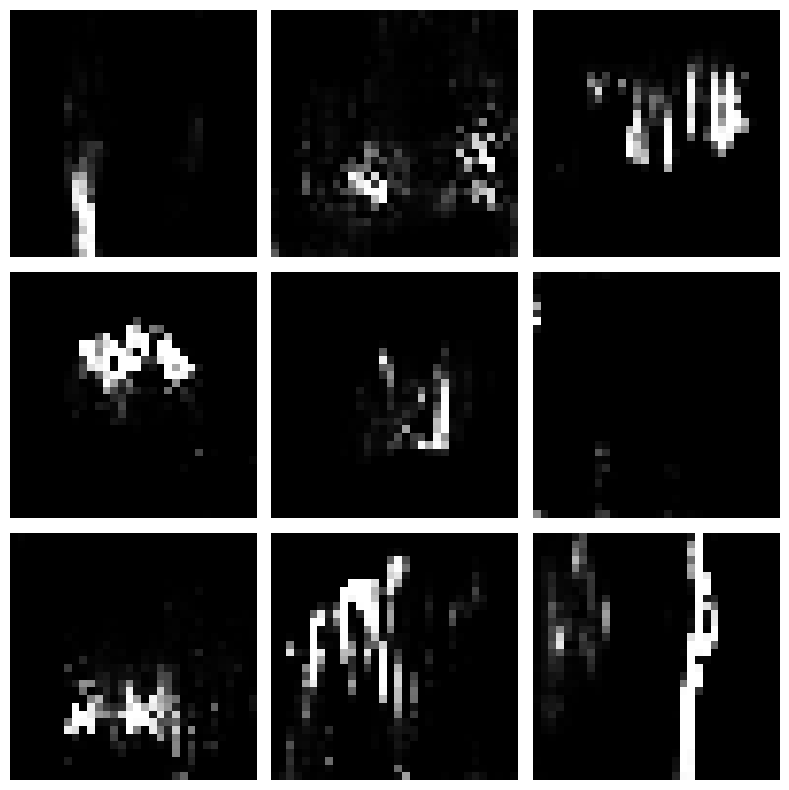

In [8]:
G.eval()
with torch.no_grad():
    syn = G(sample_z(9)).cpu().numpy()

syn = (syn + 1.0) / 2.0  # back to [0,1]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    patch = syn[i, 0]
    mid = patch[patch.shape[0] // 2]
    ax.imshow(mid, cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()